In [1]:
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Load all of the necessary files
f_mc = uproot.open("../dataloc/WithTracks_ZjetOmnifold_May19_MGPy8FxFxRew_syst_test_Mar0723.root")
f_pd = uproot.open("../dataloc/WithTracks_ZjetOmnifold_Aug5_PseudoDataSRew_Apr8_1_All.root")
f_truthpd = uproot.open("../dataloc/WithTracks_TruthPseudodata_Mar12_Combined_1_40.root")

In [3]:
# Get trees
t_mc = f_mc["OmniTree"]
t_pd = f_pd["OmniTree"]
t_truthpd = f_truthpd["OmniTree"]

In [4]:
# Get Ntracks
mc_Ntracks = ak.to_numpy(t_mc["Ntracks"].array())
truthmc_Ntracks = ak.to_numpy(t_mc["truth_Ntracks"].array())
pd_Ntracks = ak.to_numpy(t_pd["Ntracks"].array())
truthpd_Ntracks = ak.to_numpy(t_truthpd["Ntracks"].array())

In [5]:
# Get weights
mc_weights = ak.to_numpy(t_mc["weight"].array())
pd_weights = ak.to_numpy(t_pd["weight"].array())
truthpd_weights = ak.to_numpy(t_truthpd["weight"].array())

In [9]:
# Get filters
mc_filter = np.logical_and(ak.to_numpy(t_mc["pass190"].array()), ak.to_numpy(t_mc["truth_pass190"].array()))
pd_filter = np.logical_and(ak.to_numpy(t_pd["pass190"].array()), ak.to_numpy(t_pd["truth_pass190"].array()))
truthpd_filter = np.logical_and(ak.to_numpy(t_truthpd["pass190"].array()), ak.to_numpy(t_truthpd["truth_pass190"].array()))

In [10]:
print(mc_weights[:10])
print(pd_weights[:10])
print(truthpd_weights[:10])

[0.1720199  0.7602109  0.16317195 0.6460059  0.28786522 0.4371424
 0.09420745 1.0022793  0.6858111  0.8042386 ]
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
[0.00108557 0.00919603 0.00106818 0.00143196 0.0096484  0.01283303
 0.00783086 0.00684064 0.00120844 0.00999267]


In [11]:
# Get histogram of Ntracks
bins =  np.arange(0, 264, 1)
mc_h_Ntracks, edges = np.histogram(mc_Ntracks[mc_filter == 1], bins=bins, density=True, weights=mc_weights[mc_filter == 1])
truthmc_h_Ntracks, edges = np.histogram(truthmc_Ntracks[mc_filter == 1], bins=bins, density=True, weights=mc_weights[mc_filter == 1])
pd_h_Ntracks, edges = np.histogram(pd_Ntracks[pd_filter == 1], bins=bins, density=True, weights=pd_weights[pd_filter == 1])
truthpd_h_Ntracks, edges = np.histogram(truthpd_Ntracks[truthpd_filter == 1], bins=bins, density=True, weights=truthpd_weights[truthpd_filter == 1])

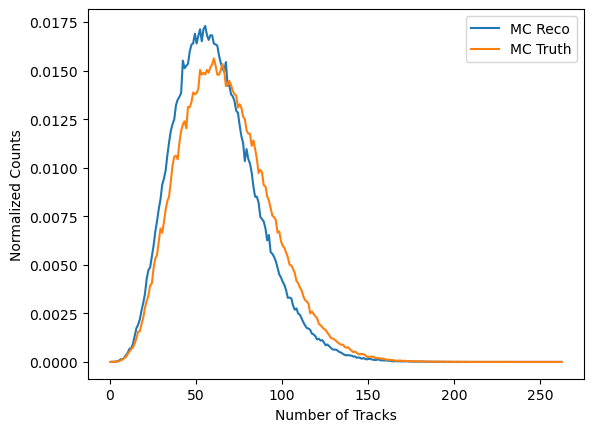

In [12]:
# Plot histograms of Ntracks for MC at truth and reco
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.plot(bin_centers, mc_h_Ntracks, label="MC Reco")
plt.plot(bin_centers, truthmc_h_Ntracks, label="MC Truth")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Normalized Counts")
plt.show()

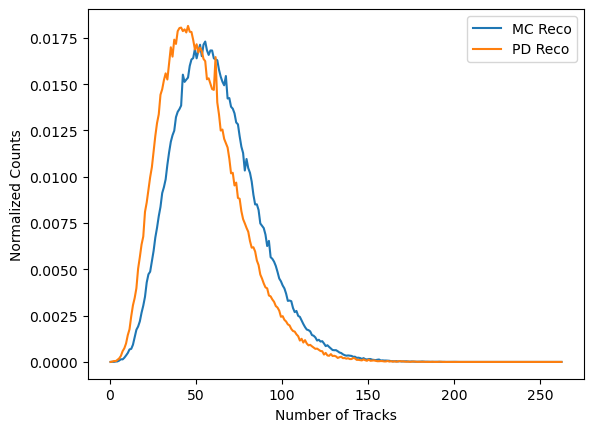

In [16]:
# Plot histograms of Ntracks of MC and PD at reco
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.plot(bin_centers, mc_h_Ntracks, label="MC Reco")
plt.plot(bin_centers, pd_h_Ntracks, label="PD Reco")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Normalized Counts")
plt.show()

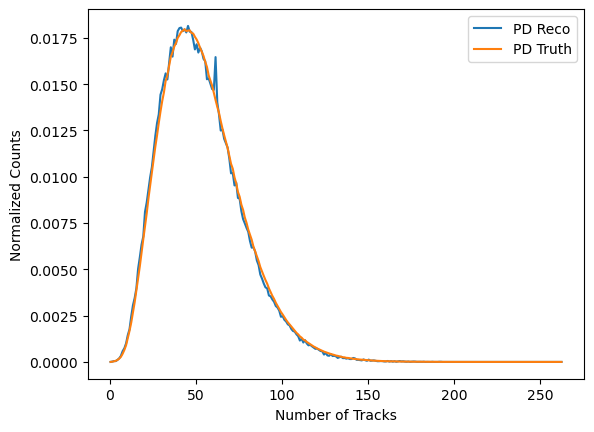

In [13]:
# Plot histograms of Ntracks for PD at truth and reco
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.plot(bin_centers, pd_h_Ntracks, label="PD Reco")
plt.plot(bin_centers, truthpd_h_Ntracks, label="PD Truth")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Normalized Counts")
plt.show()

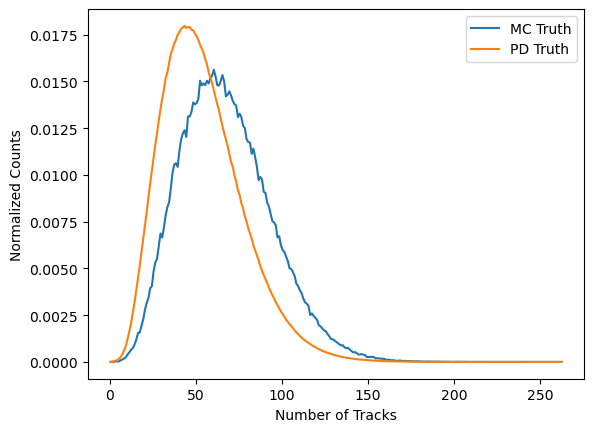

In [17]:
# Plot histograms of Ntracks for MC and PD at truth
bin_centers = (edges[:-1] + edges[1:]) / 2
plt.plot(bin_centers, truthmc_h_Ntracks, label="MC Truth")
plt.plot(bin_centers, truthpd_h_Ntracks, label="PD Truth")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Normalized Counts")
plt.show()

/tmp/ipykernel_855932/1356270511.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(bin_centers, truthmc_h_Ntracks/mc_h_Ntracks, label="MC")
/tmp/ipykernel_855932/1356270511.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(bin_centers, truthmc_h_Ntracks/mc_h_Ntracks, label="MC")
/tmp/ipykernel_855932/1356270511.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(bin_centers, truthpd_h_Ntracks/pd_h_Ntracks, label="Pseudodata")
/tmp/ipykernel_855932/1356270511.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(bin_centers, truthpd_h_Ntracks/pd_h_Ntracks, label="Pseudodata")


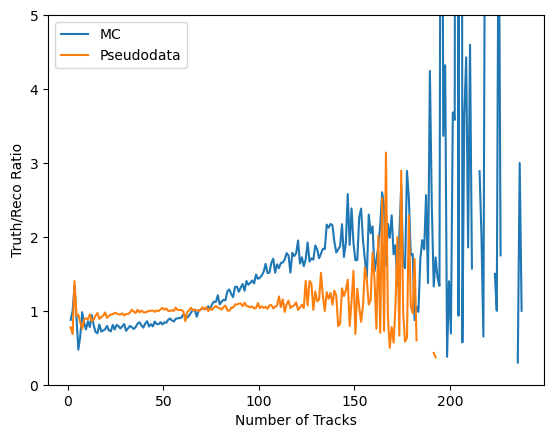

In [14]:
# Plot ratio of truth to MC for both MC and PD
plt.plot(bin_centers, truthmc_h_Ntracks/mc_h_Ntracks, label="MC")
plt.plot(bin_centers, truthpd_h_Ntracks/pd_h_Ntracks, label="Pseudodata")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Truth/Reco Ratio")
plt.ylim(0, 5)
plt.show()

/tmp/ipykernel_855932/854176690.py:2: RuntimeWarning: divide by zero encountered in divide
  plt.plot(bin_centers, pd_h_Ntracks/mc_h_Ntracks, label="Reco")
/tmp/ipykernel_855932/854176690.py:2: RuntimeWarning: invalid value encountered in divide
  plt.plot(bin_centers, pd_h_Ntracks/mc_h_Ntracks, label="Reco")
/tmp/ipykernel_855932/854176690.py:3: RuntimeWarning: divide by zero encountered in divide
  plt.plot(bin_centers, truthpd_h_Ntracks/truthmc_h_Ntracks, label="Truth")
/tmp/ipykernel_855932/854176690.py:3: RuntimeWarning: invalid value encountered in divide
  plt.plot(bin_centers, truthpd_h_Ntracks/truthmc_h_Ntracks, label="Truth")


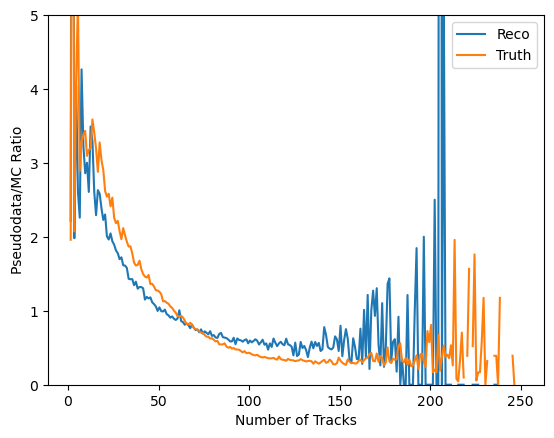

In [15]:
# Plot ratio between PD and MC for both truth and reco
plt.plot(bin_centers, pd_h_Ntracks/mc_h_Ntracks, label="Reco")
plt.plot(bin_centers, truthpd_h_Ntracks/truthmc_h_Ntracks, label="Truth")
plt.legend()
plt.xlabel("Number of Tracks")
plt.ylabel("Pseudodata/MC Ratio")
plt.ylim(0, 5)
plt.show()